In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
# Load data
df = pd.read_csv("NCRB_Table_1A.1.csv")
df.head()

,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [9]:
shape_info = df.shape
print(f"The dataset contains {shape_info[0]} rows and consists of {shape_info[1]} distinct columns.")

The dataset contains 39 rows and consists of 8 distinct columns.


In [25]:
# --- TECHNICAL AUDIT ---
print("🔍 DATASET OVERVIEW (Types & Counts)")
print("-" * 40)
df.info()  

🔍 DATASET OVERVIEW (Types & Counts)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 8 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Sl. No.                                          39 non-null     object 
 1   State/UT                                         39 non-null     object 
 2   2020                                             39 non-null     int64  
 3   2021                                             39 non-null     int64  
 4   2022                                             39 non-null     int64  
 5   Mid-Year Projected Population (in Lakhs) (2022)  39 non-null     float64
 6   Rate of Cognizable Crimes (IPC) (2022)           39 non-null     float64
 7   Chargesheeting Rate (2022)                       39 non-null     float64
dtypes: float64(3), int64(3), object(2)
m

In [27]:
aggregates = ["Total State (S)", "Total UT(S)", "Total All India"]
df_clean = df[~df['State/UT'].isin(aggregates)].copy()

In [29]:
# 1. Null Value Check
null_summary = df_clean.isnull().sum()
total_nulls = null_summary.sum()

# 2. Basic Statistics (Min/Max) for Numeric Columns
numeric_summary = df_clean[['2022', 'Rate of Cognizable Crimes (IPC) (2022)', 'Chargesheeting Rate (2022)']].agg(['min', 'max'])

print(f"--- Data Health Check ---")
print(f"Total Null Values found: {total_nulls}")
print(null_summary[null_summary > 0] if total_nulls > 0 else "Dataset is clean (No Nulls).")
print("\n--- Numeric Ranges (2022) ---")
print(numeric_summary)

--- Data Health Check ---
Total Null Values found: 0
Dataset is clean (No Nulls).

--- Numeric Ranges (2022) ---
       2022  Rate of Cognizable Crimes (IPC) (2022)  Chargesheeting Rate (2022)
min      64                                    45.4                        10.4
max  401787                                  1424.1                        96.0


In [33]:
cols_to_fix = ['2020', '2021', '2022']
for col in cols_to_fix:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# --- 2020 Observations ---
min_20 = df_clean.loc[df_clean['2020'].idxmin()]
max_20 = df_clean.loc[df_clean['2020'].idxmax()]
print(f"Year 2020: Min Crimes in {min_20['State/UT']} ({min_20['2020']:.0f}), Max Crimes in {max_20['State/UT']} ({max_20['2020']:.0f})")

# --- 2021 Observations ---
min_21 = df_clean.loc[df_clean['2021'].idxmin()]
max_21 = df_clean.loc[df_clean['2021'].idxmax()]
print(f"Year 2021: Min Crimes in {min_21['State/UT']} ({min_21['2021']:.0f}), Max Crimes in {max_21['State/UT']} ({max_21['2021']:.0f})")

# --- 2022 Observations ---
min_22 = df_clean.loc[df_clean['2022'].idxmin()]
max_22 = df_clean.loc[df_clean['2022'].idxmax()]
print(f"Year 2022: Min Crimes in {min_22['State/UT']} ({min_22['2022']:.0f}), Max Crimes in {max_22['State/UT']} ({max_22['2022']:.0f})")

Year 2020: Min Crimes in Lakshadweep (107), Max Crimes in Tamil Nadu (891700)
Year 2021: Min Crimes in Lakshadweep (89), Max Crimes in Maharashtra (367218)
Year 2022: Min Crimes in Lakshadweep (64), Max Crimes in Uttar Pradesh (401787)


In [39]:
print(f"✅ CLEANING SUCCESSFUL: Removed aggregate rows.")
print(f"Number of individual States/UTs being analyzed: {df_clean.shape[0]}")

print("\n🔍 [STEP 1] DATA ARCHITECTURE (df.info())")
print("-" * 65)
df_clean.info()

print("\n📊 [STEP 2] REAL STATISTICAL LANDSCAPE (df.describe())")
print("-" * 65)
# This now shows the true average and spread of individual states
print(df_clean.describe())

print("\n" + "="*75)
print(f"{'YEAR':<6} | {'METRIC':<10} | {'STATE / UT':<25} | {'VALUE':>15}")
print("="*75)

for year in ['2020', '2021', '2022']:
    col = f'{year}'
    temp_df = df_clean.dropna(subset=[col])
    
    if not temp_df.empty:
        mx_idx = temp_df[col].idxmax()
        mn_idx = temp_df[col].idxmin()
        
        mx_state, mx_val = temp_df.loc[mx_idx, 'State/UT'], temp_df.loc[mx_idx, col]
        mn_state, mn_val = temp_df.loc[mn_idx, 'State/UT'], temp_df.loc[mn_idx, col]

        print(f"{year:<6} | {'MAX':<10} | {mx_state:<25} | {mx_val:>15.4f}")
        print(f"{year:<6} | {'MIN':<10} | {mn_state:<25} | {mn_val:>15.4f}")
        print("-" * 75)

✅ CLEANING SUCCESSFUL: Removed aggregate rows.
Number of individual States/UTs being analyzed: 36

🔍 [STEP 1] DATA ARCHITECTURE (df.info())
-----------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 0 to 36
Data columns (total 8 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Sl. No.                                          36 non-null     object 
 1   State/UT                                         36 non-null     object 
 2   2020                                             36 non-null     int64  
 3   2021                                             36 non-null     int64  
 4   2022                                             36 non-null     int64  
 5   Mid-Year Projected Population (in Lakhs) (2022)  36 non-null     float64
 6   Rate of Cognizable Crimes (IPC) (2022)           36 non-null     flo

In [43]:
# 1. Calculate Benchmarks
mean_rate = df_clean['Rate of Cognizable Crimes (IPC) (2022)'].mean()
std_rate = df_clean['Rate of Cognizable Crimes (IPC) (2022)'].std()
outlier_threshold = mean_rate + (2 * std_rate)

# 2. Identify High-Risk Outliers (Crime Rate)
outliers_rate = df_clean[df_clean['Rate of Cognizable Crimes (IPC) (2022)'] > outlier_threshold]

# 3. Identify Performance Outliers (Low Chargesheet Rate)
mean_eff = df_clean['Chargesheeting Rate (2022)'].mean()
low_eff_threshold = mean_eff - (1.5 * df_clean['Chargesheeting Rate (2022)'].std())
underperformers = df_clean[df_clean['Chargesheeting Rate (2022)'] < low_eff_threshold]

# --- THE REPORT ---

print(f"📊 STATISTICAL BENCHMARKS (2022)")
print(f"Avg Crime Rate: {mean_rate:.4f} | Outlier Threshold: >{outlier_threshold:.4f}")
print(f"Avg Efficiency: {mean_eff:.4f}% | Low Efficiency Threshold: <{low_eff_threshold:.4f}%")
print("-" * 75)

# Adding the Interpretation Logic
print("📝 INTERPRETATION:")
print(f"• States with a Crime Rate above {outlier_threshold:.2f} are considered 'High Intensity' zones.")
print(f"• Efficiency below {low_eff_threshold:.2f}% indicates a significant justice delivery gap.")
print("-" * 75)

print("\n🚩 [CRIME RATE OUTLIERS]")
if not outliers_rate.empty:
    for _, row in outliers_rate.iterrows():
        print(f"-> {row['State/UT']}: Rate is {row['Rate of Cognizable Crimes (IPC) (2022)']:.4f} (Extremely High)")
else:
    print("No statistical outliers found for Crime Rate.")

print("\n📉 [EFFICIENCY ANOMALIES]")
if not underperformers.empty:
    for _, row in underperformers.iterrows():
        print(f"-> {row['State/UT']}: Chargesheet Rate is {row['Chargesheeting Rate (2022)']:.4f}% (Critically Low)")
else:
    print("No critical efficiency anomalies found.")

📊 STATISTICAL BENCHMARKS (2022)
Avg Crime Rate: 241.2528 | Outlier Threshold: >712.2991
Avg Efficiency: 67.9917% | Low Efficiency Threshold: <37.4901%
---------------------------------------------------------------------------
📝 INTERPRETATION:
• States with a Crime Rate above 712.30 are considered 'High Intensity' zones.
• Efficiency below 37.49% indicates a significant justice delivery gap.
---------------------------------------------------------------------------

🚩 [CRIME RATE OUTLIERS]
-> Delhi: Rate is 1424.1000 (Extremely High)

📉 [EFFICIENCY ANOMALIES]
-> Assam: Chargesheet Rate is 32.6000% (Critically Low)
-> Manipur: Chargesheet Rate is 10.4000% (Critically Low)
-> Meghalaya: Chargesheet Rate is 26.9000% (Critically Low)
-> Delhi: Chargesheet Rate is 30.2000% (Critically Low)


In [45]:
# 1. Calculate the Percentage Growth
# Formula: ((New - Old) / Old) * 100
df_clean['Growth_20_22_Pct'] = ((df_clean['2022'] - df_clean['2020']) / df_clean['2020']) * 100

# 2. Sort by Growth to find the sharpest increases
df_growth_sorted = df_clean.sort_values(by='Growth_20_22_Pct', ascending=False)

# 3. National Average Growth (for benchmarking)
national_avg_growth = df_clean['Growth_20_22_Pct'].mean()

print(f"📊 TREND SUMMARY (2020-2022)")
print(f"Average State-wise Growth: {national_avg_growth:.4f}%")
print("-" * 75)

print("\n🚀 [TOP 5 STATES WITH HIGHEST CRIME SURGE]")
for i, row in df_growth_sorted.head(5).iterrows():
    print(f"{i+1}. {row['State/UT']:<25} | Growth: {row['Growth_20_22_Pct']:>8.4f}%")

print("\n✅ [TOP 5 STATES WITH HIGHEST CRIME REDUCTION]")
# Sorting ascending to see the most negative growth (improvement)
for i, row in df_growth_sorted.tail(5).iloc[::-1].iterrows():
    print(f"-> {row['State/UT']:<25} | Change: {row['Growth_20_22_Pct']:>8.4f}%")

📊 TREND SUMMARY (2020-2022)
Average State-wise Growth: 6.2710%
---------------------------------------------------------------------------

🚀 [TOP 5 STATES WITH HIGHEST CRIME SURGE]
32. Dadra and Nagar Haveli and Daman and Diu | Growth: 168.4807%
17. Mizoram                   | Growth: 100.7275%
12. Kerala                    | Growth:  58.1889%
19. Odisha                    | Growth:  32.1386%
15. Manipur                   | Growth:  28.9485%

✅ [TOP 5 STATES WITH HIGHEST CRIME REDUCTION]
-> Tamil Nadu                | Change: -78.2536%
-> Gujarat                   | Change: -64.7505%
-> Puducherry                | Change: -51.8662%
-> Assam                     | Change: -46.8303%
-> Lakshadweep               | Change: -40.1869%


In [47]:
# 1. Calculate Correlation between Population and Growth
correlation_val = df_clean['Mid-Year Projected Population (in Lakhs) (2022)'].corr(df_clean['Growth_20_22_Pct'])

# 2. Segment the Data: High Pop vs. Low Pop Growth
median_pop = df_clean['Mid-Year Projected Population (in Lakhs) (2022)'].median()
high_pop_growth = df_clean[df_clean['Mid-Year Projected Population (in Lakhs) (2022)'] > median_pop]['Growth_20_22_Pct'].mean()
low_pop_growth = df_clean[df_clean['Mid-Year Projected Population (in Lakhs) (2022)'] <= median_pop]['Growth_20_22_Pct'].mean()

print(f"🧬 CORRELATION ANALYSIS")
print(f"Pearson Correlation (Population vs Growth): {correlation_val:.4f}")
print("-" * 75)

print("📝 INTERPRETATION:")
if abs(correlation_val) < 0.3:
    print("• WEAK CORRELATION: The surge in crime is NOT limited to high-population states.")
    print("  It is likely driven by localized issues rather than general urbanization.")
elif 0.3 <= correlation_val < 0.7:
    print("• MODERATE CORRELATION: There is a visible link between population size and crime surge.")
else:
    print("• STRONG CORRELATION: Crime is surging predominantly in highly populated/urbanized areas.")

print(f"\n📊 COMPARATIVE GROWTH")
print(f"• Avg Growth in High-Pop States: {high_pop_growth:.4f}%")
print(f"• Avg Growth in Low-Pop States:  {low_pop_growth:.4f}%")
print("-" * 75)

🧬 CORRELATION ANALYSIS
Pearson Correlation (Population vs Growth): -0.1244
---------------------------------------------------------------------------
📝 INTERPRETATION:
• WEAK CORRELATION: The surge in crime is NOT limited to high-population states.
  It is likely driven by localized issues rather than general urbanization.

📊 COMPARATIVE GROWTH
• Avg Growth in High-Pop States: -1.1930%
• Avg Growth in Low-Pop States:  13.7349%
---------------------------------------------------------------------------


In [49]:
# 1. Normalizing the factors (Scaling 0 to 1)
# For Efficiency: Higher is better
df_clean['Eff_Score'] = (df_clean['Chargesheeting Rate (2022)'] - df_clean['Chargesheeting Rate (2022)'].min()) / \
                        (df_clean['Chargesheeting Rate (2022)'].max() - df_clean['Chargesheeting Rate (2022)'].min())

# For Crime Rate & Growth: Lower is better (so we invert the score)
df_clean['Risk_Score'] = 1 - (df_clean['Rate of Cognizable Crimes (IPC) (2022)'] - df_clean['Rate of Cognizable Crimes (IPC) (2022)'].min()) / \
                             (df_clean['Rate of Cognizable Crimes (IPC) (2022)'].max() - df_clean['Rate of Cognizable Crimes (IPC) (2022)'].min())

df_clean['Growth_Score'] = 1 - (df_clean['Growth_20_22_Pct'] - df_clean['Growth_20_22_Pct'].min()) / \
                               (df_clean['Growth_20_22_Pct'].max() - df_clean['Growth_20_22_Pct'].min())

# 2. Final Weighted Score (0 to 100)
df_clean['Safety_Index'] = (df_clean['Eff_Score'] * 0.40 + 
                            df_clean['Risk_Score'] * 0.30 + 
                            df_clean['Growth_Score'] * 0.30) * 100

# 3. Sort for Ranking
df_ranked = df_clean.sort_values(by='Safety_Index', ascending=False)

print(f"📊 FINAL STATE SAFETY RANKINGS (Weighted SPI)")
print("-" * 85)
print(f"{'RANK':<5} | {'STATE / UT':<25} | {'INDEX SCORE':>12} | {'STATUS'}")
print("-" * 85)

for i, (idx, row) in enumerate(df_ranked.iterrows(), 1):
    status = "🟢 Exemplary" if row['Safety_Index'] > 70 else "🟡 Stable" if row['Safety_Index'] > 40 else "🔴 Critical"
    print(f"{i:<5} | {row['State/UT']:<25} | {row['Safety_Index']:>12.4f} | {status}")

print("-" * 85)

📊 FINAL STATE SAFETY RANKINGS (Weighted SPI)
-------------------------------------------------------------------------------------
RANK  | STATE / UT                |  INDEX SCORE | STATUS
-------------------------------------------------------------------------------------
1     | Gujarat                   |      92.3189 | 🟢 Exemplary
2     | Puducherry                |      91.2378 | 🟢 Exemplary
3     | West Bengal               |      85.6207 | 🟢 Exemplary
4     | Andaman and Nicobar Islands |      83.8846 | 🟢 Exemplary
5     | Lakshadweep               |      83.8261 | 🟢 Exemplary
6     | Tamil Nadu                |      83.6646 | 🟢 Exemplary
7     | Himachal Pradesh          |      82.7740 | 🟢 Exemplary
8     | Andhra Pradesh            |      82.4867 | 🟢 Exemplary
9     | Goa                       |      80.7645 | 🟢 Exemplary
10    | Ladakh                    |      80.2900 | 🟢 Exemplary
11    | Tripura                   |      79.9246 | 🟢 Exemplary
12    | Madhya Pradesh        

In [51]:
# 1. Define the Benchmarks from our previous steps
avg_growth = df_clean['Growth_20_22_Pct'].mean()
# Low Efficiency Threshold was calculated as < 37.4901% in our previous run

# 2. Filter for states in the 'Overload' zone
overloaded_states = df_clean[
    (df_clean['Chargesheeting Rate (2022)'] < 37.4901) & 
    (df_clean['Growth_20_22_Pct'] > avg_growth)
]

print(f"🕵️ CROSS-REFERENCE: EFFICIENCY vs. GROWTH")
print(f"National Avg Growth: {avg_growth:.4f}% | Efficiency Threshold: <37.4901%")
print("-" * 85)

if not overloaded_states.empty:
    print(f"{'STATE / UT':<25} | {'GROWTH RATE':>12} | {'EFFICIENCY':>12}")
    print("-" * 85)
    for _, row in overloaded_states.iterrows():
        print(f"{row['State/UT']:<25} | {row['Growth_20_22_Pct']:>11.4f}% | {row['Chargesheeting Rate (2022)']:>11.4f}%")
    
    print("\n📝 INTERPRETATION:")
    print("⚠️ CRITICAL OVERLOAD: The states above are seeing crimes rise faster than the average,")
    print("yet their police forces are filing chargesheets at a critically low rate.")
    print("This combination often leads to a massive backlog in the judicial system.")
else:
    print("✅ NO CRITICAL OVERLOAD: No states currently meet both 'Low Efficiency' and 'High Growth' criteria.")

🕵️ CROSS-REFERENCE: EFFICIENCY vs. GROWTH
National Avg Growth: 6.2710% | Efficiency Threshold: <37.4901%
-------------------------------------------------------------------------------------
STATE / UT                |  GROWTH RATE |   EFFICIENCY
-------------------------------------------------------------------------------------
Manipur                   |     28.9485% |     10.4000%
Delhi                     |     20.5613% |     30.2000%

📝 INTERPRETATION:
⚠️ CRITICAL OVERLOAD: The states above are seeing crimes rise faster than the average,
yet their police forces are filing chargesheets at a critically low rate.
This combination often leads to a massive backlog in the judicial system.


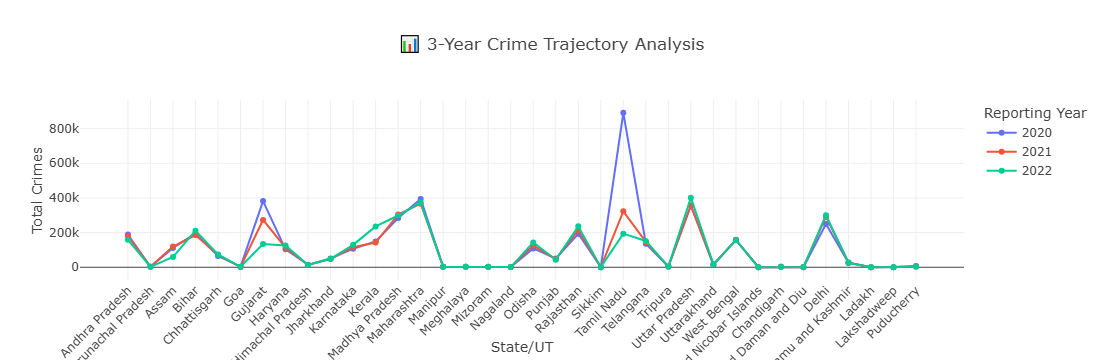

In [83]:
df_line = df_clean.melt(id_vars='State/UT', 
                        value_vars=['2020', '2021', '2022'],
                        var_name='Year', value_name='Total Crimes')
df_line['Year'] = df_line['Year'].str.replace('Crimes_', '')

# --- i) Line Graph: 3 Distinct Years ---
fig_line = px.line(df_line, x='State/UT', y='Total Crimes', color='Year', markers=True,
                   title='📊 3-Year Crime Trajectory Analysis',
                   # Setting custom distinct colors for each year line
                   color_discrete_map={'2020': '#636EFA', '2021': '#EF553B', '2022': '#00CC96'})

fig_line.update_layout(
    xaxis_tickangle=-45,
    plot_bgcolor='rgba(0,0,0,0)', # Transparent background
    hovermode="x unified",       # Shows all 3 years at once when hovering
    legend_title_text='Reporting Year'
)

# --- ii) Bar Graph: Comparative 2020 vs 2022 ---
fig_bar = px.bar(df_clean, x='State/UT', y=['2020', '2022'],
                 barmode='group',
                 title='📉 Volume Comparison: 2020 vs 2022',
                 # Using a contrasting color pair
                 color_discrete_sequence=['#AB63FA', '#FFA15A']) 

# Clean up Legend labels
fig_bar.for_each_trace(lambda t: t.update(name = t.name.replace('Crimes_', '')))

fig_bar.update_layout(
    xaxis_tickangle=-45,
    bargap=0.2, 
    bargroupgap=0.1,
    xaxis_title="State / Union Territory",
    yaxis_title="Total Number of Crimes"
)

# Display the interactive results
fig_line.show()


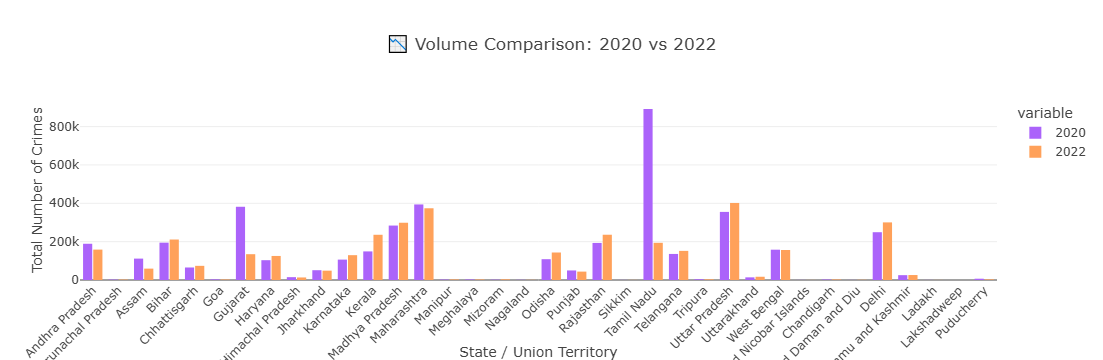

In [85]:
fig_bar.show()

In [81]:
# 1. Calculating Volume Metrics
df_clean["Chargesheeted_Cases_2022"] = (df_clean["2022"] * df_clean["Chargesheeting Rate (2022)"] / 100)
df_clean["Pending_Cases_2022"] = df_clean["2022"] - df_clean["Chargesheeted_Cases_2022"]

# Rounding to 4 decimals as per your preference
df_clean["Chargesheeted_Cases_2022"] = df_clean["Chargesheeted_Cases_2022"].round(4)
df_clean["Pending_Cases_2022"] = df_clean["Pending_Cases_2022"].round(4)

# 2. Sorting to find the states with the highest pending workload
df_backlog = df_clean.sort_values(by="Pending_Cases_2022", ascending=False)

print(f"⚖️ JUDICIAL WORKLOAD & BACKLOG REPORT (2022)")
print("-" * 85)
print(f"{'STATE / UT':<25} | {'TOTAL CRIMES':>12} | {'CHARGESHEETED':>14} | {'PENDING':>12}")
print("-" * 85)

for i, row in df_backlog.head(10).iterrows():
    print(f"{row['State/UT']:<25} | {row['2022']:>12.0f} | {row['Chargesheeted_Cases_2022']:>14.2f} | {row['Pending_Cases_2022']:>12.2f}")

print("-" * 85)

⚖️ JUDICIAL WORKLOAD & BACKLOG REPORT (2022)
-------------------------------------------------------------------------------------
STATE / UT                | TOTAL CRIMES |  CHARGESHEETED |      PENDING
-------------------------------------------------------------------------------------
Delhi                     |       300429 |       90729.56 |    209699.44
Rajasthan                 |       236090 |      117572.82 |    118517.18
Uttar Pradesh             |       401787 |      305759.91 |     96027.09
Maharashtra               |       374038 |      281650.61 |     92387.39
Haryana                   |       125435 |       54313.36 |     71121.65
Tamil Nadu                |       193913 |      137096.49 |     56816.51
Bihar                     |       211079 |      159153.57 |     51925.43
Madhya Pradesh            |       298578 |      258568.55 |     40009.45
Assam                     |        59315 |       19336.69 |     39978.31
Telangana                 |       151849 |      12011

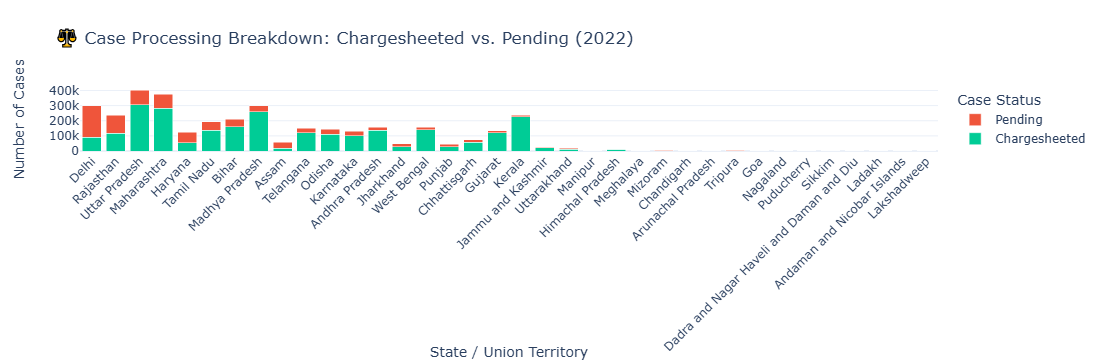

In [73]:
fig_workload = go.Figure(data=[
    go.Bar(name='Chargesheeted', x=df_backlog['State/UT'], y=df_backlog['Chargesheeted_Cases_2022'], marker_color='#00CC96'),
    go.Bar(name='Pending', x=df_backlog['State/UT'], y=df_backlog['Pending_Cases_2022'], marker_color='#EF553B')
])

# Change the bar mode to stack
fig_workload.update_layout(
    barmode='stack',
    title='⚖️ Case Processing Breakdown: Chargesheeted vs. Pending (2022)',
    xaxis_tickangle=-45,
    xaxis_title="State / Union Territory",
    yaxis_title="Number of Cases",
    legend_title="Case Status",
    template="plotly_white"
)

fig_workload.show()

In [87]:
# 1. Define Medians for the thresholds
pop_median = df_clean['Mid-Year Projected Population (in Lakhs) (2022)'].median()
rate_median = df_clean['2022'].median()
eff_median = df_clean['Chargesheeting Rate (2022)'].median()

# 2. Identify the "Vulnerable Small Zones"
vulnerable_zones = df_clean[
    (df_clean['Mid-Year Projected Population (in Lakhs) (2022)'] < pop_median) & 
    (df_clean['2022'] > rate_median) & 
    (df_clean['Chargesheeting Rate (2022)'] < eff_median)
]

print(f"🕵️ VULNERABILITY SUMMARY: LOW POPULATION / HIGH RISK")
print(f"Benchmarks: Pop < {pop_median:.1f} Lakhs | Rate > {rate_median:.1f} | Efficiency < {eff_median:.1f}%")
print("-" * 95)

if not vulnerable_zones.empty:
    print(f"{'STATE / UT':<25} | {'POPULATION':>10} | {'CRIME RATE':>12} | {'EFFICIENCY':>12}")
    print("-" * 95)
    for _, row in vulnerable_zones.iterrows():
        print(f"{row['State/UT']:<25} | {row['Mid-Year Projected Population (in Lakhs) (2022)']:>10.2f} | {row['2022']:>12.2f} | {row['Chargesheeting Rate (2022)']:>11.2f}%")
else:
    print("✅ No regions currently match the high-risk/low-population criteria.")

🕵️ VULNERABILITY SUMMARY: LOW POPULATION / HIGH RISK
Benchmarks: Pop < 255.2 Lakhs | Rate > 46232.0 | Efficiency < 75.3%
-----------------------------------------------------------------------------------------------
STATE / UT                | POPULATION |   CRIME RATE |   EFFICIENCY
-----------------------------------------------------------------------------------------------
Delhi                     |     211.00 |    300429.00 |       30.20%


In [91]:
# List of Union Territories for classification
union_territories = [
    "Andaman and Nicobar Islands", "Chandigarh", 
    "Dadra and Nagar Haveli and Daman and Diu", "Delhi", 
    "Jammu and Kashmir", "Ladakh", "Lakshadweep", "Puducherry"
]

# Create the new column: 0 for UTs, 1 for States
df_clean['state_ut'] = df_clean['State/UT'].apply(lambda x: 0 if x in union_territories else 1)

# Verify the classification
print(df_clean[['State/UT', 'state_ut']].to_string())

                                    State/UT  state_ut
0                             Andhra Pradesh         1
1                          Arunachal Pradesh         1
2                                      Assam         1
3                                      Bihar         1
4                               Chhattisgarh         1
5                                        Goa         1
6                                    Gujarat         1
7                                    Haryana         1
8                           Himachal Pradesh         1
9                                  Jharkhand         1
10                                 Karnataka         1
11                                    Kerala         1
12                            Madhya Pradesh         1
13                               Maharashtra         1
14                                   Manipur         1
15                                 Meghalaya         1
16                                   Mizoram         1
17        

In [93]:
# 1. Select features for the ML model
features = ['2022', 'Chargesheeting Rate (2022)', 'Growth_20_22_Pct']
x = df_clean[features]

# 2. Scale the data (Crucial for ML)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 3. Apply K-Means (Grouping into 3 Clusters: Safe, Moderate, Concerning)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(x_scaled)

# 4. Interpret the Clusters
cluster_summary = df_clean.groupby('Cluster')[features].mean()
print("🤖 MACHINE LEARNING CLUSTER PROFILES:")
print(cluster_summary)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



🤖 MACHINE LEARNING CLUSTER PROFILES:
                  2022  Chargesheeting Rate (2022)  Growth_20_22_Pct
Cluster                                                             
0        120602.782609                   80.030435         -4.825519
1         71158.545455                   42.409091          6.139371
2          2385.500000                   70.250000        134.604101


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



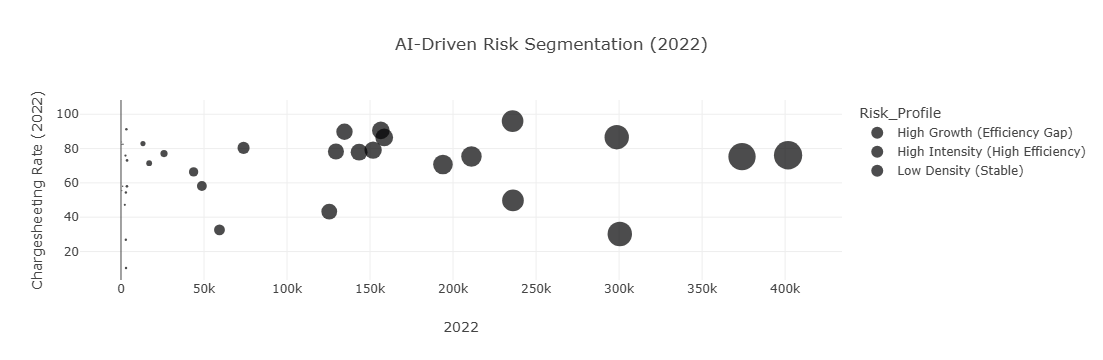

In [101]:
# 1. Feature selection
ml_features = ['2022', 'Chargesheeting Rate (2022)', 'Growth_20_22_Pct']
df_ml = df_clean.dropna(subset=ml_features).copy()

# 2. Standardization (Ensures 'Rate' and 'Growth' have equal weight)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_ml[ml_features])

# 3. K-Means (Grouping into 3 Risk Zones)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(x_scaled)

# 4. Human-Readable Mapping
# Note: Check your specific centroid values to ensure the mapping matches the logic above
risk_map = {1: "High Intensity (High Efficiency)", 0: "High Growth (Efficiency Gap)", 2: "Low Density (Stable)"}
df_ml['Risk_Profile'] = df_ml['Cluster'].map(risk_map)

# 5. Visualizing the ML Segments
fig_ml = px.scatter(df_ml, x='2022', y='Chargesheeting Rate (2022)', 
                 size='2022', color='Risk_Profile',
                 hover_name='State/UT', title='AI-Driven Risk Segmentation (2022)',
                 labels={'Crime_Rate_2022': 'Crime Rate', 'Chargesheet_Rate_2022': 'Chargesheet %'})

fig_ml.show()

In [103]:
def get_narrative(row):
    if row['Cluster'] == 0:
        return "CRITICAL: System Overload. Crime is rising faster than the police can investigate."
    elif row['Cluster'] == 1:
        return "STRESS-TEST: High volume, but high efficiency. Monitor judicial capacity."
    else:
        return "STABLE: Strong performance. Focus on maintaining low growth trends."

# Apply the narrator to each state
df_ml['AI_Narrative'] = df_ml.apply(get_narrative, axis=1)

# Display the report card for the most concerning states
print("AI-GENERATED STRATEGIC REPORT CARD")
print("-" * 85)
for i, row in df_ml[df_ml['Cluster'] == 0].head(5).iterrows():
    print(f"📍 {row['State/UT']}: {row['AI_Narrative']}")

📊 AI-GENERATED STRATEGIC REPORT CARD
-------------------------------------------------------------------------------------
📍 Andhra Pradesh: CRITICAL: System Overload. Crime is rising faster than the police can investigate.
📍 Bihar: CRITICAL: System Overload. Crime is rising faster than the police can investigate.
📍 Chhattisgarh: CRITICAL: System Overload. Crime is rising faster than the police can investigate.
📍 Goa: CRITICAL: System Overload. Crime is rising faster than the police can investigate.
📍 Gujarat: CRITICAL: System Overload. Crime is rising faster than the police can investigate.


In [108]:
# Save your final dataframe to a CSV
df_ml.to_csv("NCRB_Processed_Data.csv", index=False)
print("Data saved for PDF Export.")

Data saved for PDF Export.
